In [1]:
import pandas as pd

# load kr
stocks = pd.read_csv("data/Assignment_4/GOOG.csv")
df = stocks[["open", "close", "date"]]

# date la date banav. index pn banav tela
df["date"] = df["date"].str.extract(r"(\d\d\d\d\-\d\d-\d\d)")
df.set_index("date", inplace=True)
df.index = pd.to_datetime(df.index, format="%Y-%m-%d")

df.head()


/tmp/ipykernel_41927/4272202873.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date"] = df["date"].str.extract(r"(\d\d\d\d\-\d\d-\d\d)")


,open,close
date,,
2016-06-14,716.48,718.27
2016-06-15,719.00,718.92
2016-06-16,714.91,710.36
2016-06-17,708.65,691.72
2016-06-20,698.77,693.71


In [2]:
train_split = int(len(df) * 0.8)

train = df.iloc[:train_split, :]
test = df.iloc[train_split:, :]

train.shape, test.shape


((1006, 2), (252, 2))

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)


In [24]:
import numpy as np


def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])  # The window of past days
        y.append(data[i + seq_length])  # The target (next day's open/close)
    return np.array(X), np.array(y)


# Let's say we use a 60-day window
seq_length = 50
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

print(
    f"Train - {X_train.shape}, {y_train.shape} \n"
    f"Test - {X_test.shape}, {y_test.shape} \n",
)


Train - (956, 50, 2), (956, 2) 
Test - (202, 50, 2), (202, 2) 



In [25]:
from tensorflow.keras.layers import Dense, Dropout, Input, SimpleRNN
from tensorflow.keras.models import Sequential

model = Sequential(
    [
        Input((seq_length, 2)),
        SimpleRNN(50, activation="tanh"),
        Dropout(0.3),
        Dense(2),
    ],
)

model.compile(
    loss="mean_squared_error",
    optimizer="adam",
    metrics=["mean_absolute_error"],
)


In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    shuffle=False,
)


Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0679 - mean_absolute_error: 0.1990 - val_loss: 0.2565 - val_mean_absolute_error: 0.4218
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0270 - mean_absolute_error: 0.1261 - val_loss: 0.0992 - val_mean_absolute_error: 0.2614
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0171 - mean_absolute_error: 0.0981 - val_loss: 0.0727 - val_mean_absolute_error: 0.2244
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0146 - mean_absolute_error: 0.0912 - val_loss: 0.0679 - val_mean_absolute_error: 0.2133
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0117 - mean_absolute_error: 0.0816 - val_loss: 0.0504 - val_mean_absolute_error: 0.1874
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0097 - mean_absolute_error: 0.0750 - val_loss: 0.0381 - val_mean_absolute_error: 0.1585
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0087 - mean_absolute_error: 0.0695 - val_los

In [27]:
from sklearn.metrics import root_mean_squared_error

test_predictions = model.predict(X_test)
rmse = root_mean_squared_error(y_test, test_predictions)
print("RMSE:", rmse)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
RMSE: 0.03484574135053461


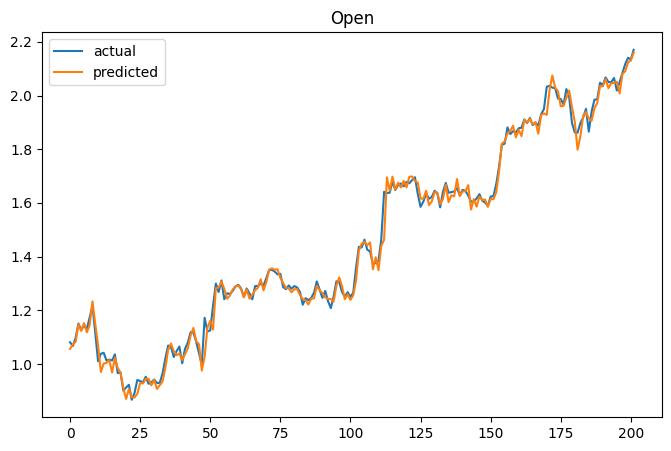

In [28]:
import matplotlib.pyplot as plt

open_actual = [i[0] for i in y_test]
open_predicted = [i[0] for i in test_predictions]
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(open_actual)), open_actual, label="actual")
plt.plot(np.arange(len(open_predicted)), open_predicted, label="predicted")
plt.legend()
plt.title("Open")
plt.show()


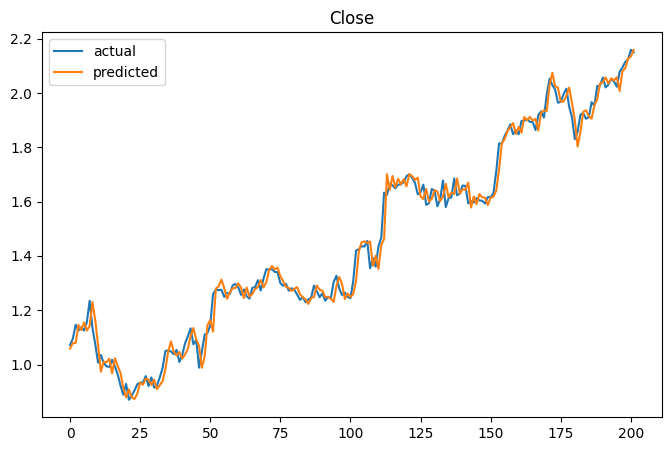

In [29]:
import matplotlib.pyplot as plt

open_actual = [i[1] for i in y_test]
open_predicted = [i[1] for i in test_predictions]
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(open_actual)), open_actual, label="actual")
plt.plot(np.arange(len(open_predicted)), open_predicted, label="predicted")
plt.legend()
plt.title("Close")
plt.show()
